<a href="https://colab.research.google.com/github/GustavoGarcia627/Analisis-num-rico---Famaf/blob/main/2026_Practico_4_numerico_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis numérico 1 - 2026

## Trabajo de Laboratorio Nº4

**Ejercicio 1 (a).** Usando el comando `loadtxt` de python (np.loadtxt), leer los datos almacenados en el archivo `datos1a.dat` ubicado en el aula virtual de la materia.

Usar las fórmulas para un ajuste lineal por cuadrados mínimos para obtener la recta que mejor aproxima estos datos. Graficar lo datos y el ajuste obtenido

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [ ]:
#Cargamos los datos
datos = "datos1a.dat"
#Arreglos con dos arreglos
hx = np.loadtxt(datos)

In [ ]:
#Estructuras que se repiten
xi = 0
xi2 =0
yi = 0
xiyi = 0
m = len(hx[0])

for i in range(m):
  xi += (hx[0][i])
  xi2 += (hx[0][i]**2)
  yi += (hx[1][i])
  xiyi += (hx[0][i]) * (hx[1][i])

#Determinamos las incognitas
a0 = (xi2 *yi - xiyi *xi)/(m*xi2 - xi**2)
a1 = (m*xiyi - xi * yi)  /(m*xi2 - xi**2)

print(f"La mejor recta que aproxima a los datos es f(x)=({a1})x + ({a0})")

La mejor recta que aproxima a los datos es f(x)=(3.202617190341157)x + (-1.8073494201428664)


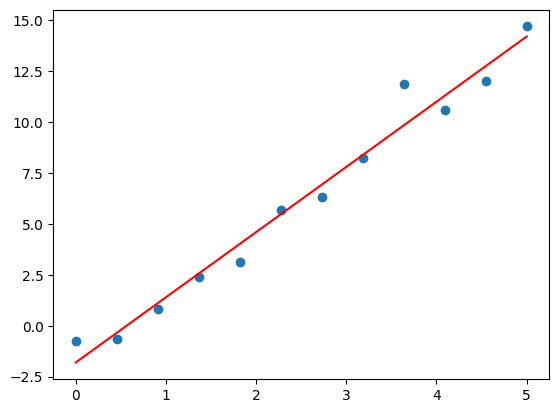

In [ ]:
# 1. Definir los datos
x = np.linspace(0, 5, 100) # 100 puntos entre 0 y 5
y = a1 * x + a0

plt.plot(x, y, color = "red",label=f'Recta: y={a1}x+{a0}')

#Graficamos lospuntos
plt.scatter(hx[0],hx[1])

**Ejercicio 1 (b)** Realizar los mismos cálculos con la ayuda de las funciones `dot`y `ones`(Numpy)

Observación:

*   `np.ones()`: Crea arreglos o matrices llenos de valores iguales a 1.
*   `np.dot()`: Calcula el producto escalar entre dos matrices



In [ ]:
#Ejercicio 1 b
m = len(hx[0])

#Arreglo 1xm de 1's
vec1 = np.ones(m)

#Estructura que se repiten
bxi = np.dot(hx[0],vec1)
bxi2= np.dot(hx[0],hx[0])
byi = np.dot(hx[1],vec1)
bxiyi=np.dot(hx[0],hx[1])

#Determinamos las incognitas
ba0 = (bxi2 *byi - bxiyi *xi)/(m*bxi2 - bxi**2)
ba1 = (m*bxiyi - bxi * byi)  /(m*bxi2 - bxi**2)

print(f"La mejor recta que aproxima a los datos es f(x)=({ba1})x + ({ba0})")

La mejor recta que aproxima a los datos es f(x)=(3.202617190341157)x + (-1.8073494201428664)


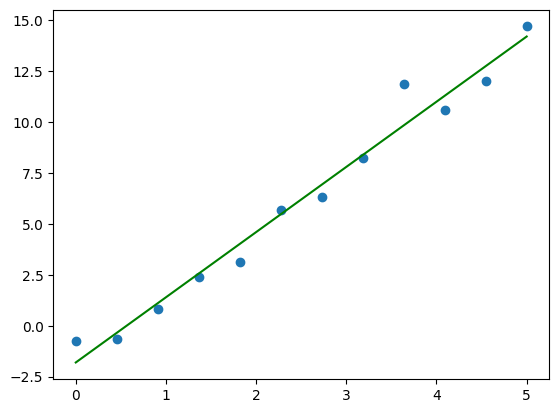

In [ ]:
# 1. Definir los datos
bx = np.linspace(0, 5, 100) # 100 puntos entre 0 y 5
by = ba1 * x + ba0

plt.plot(bx, by, color = "green",label=f'Recta: y={ba1}x+{ba0}')

#Graficamos lospuntos
plt.scatter(hx[0],hx[1])

**Ejercicio 1 (c)** Dada la recta $y = \frac{3}{4}x-\frac{1}{2}$, generar un conjunto de pares $(x_i,y_i), i = 0,\dots, 19,$ en el intervalo $[0,10]$, con dispersión normal en el eje y.

Realizar un ajuste lineal a los datos, obtener los coeficientes y dibujar el ajuste.

Investigar los comandos `linspace`, `randn`, `polyval` y `polyfit` (Numpy).

**Observación**

*   `np.linspace(a, b, n)` genera n puntos entre a y b
*   `np.random.randn()` genera arrays (matrices o vectores) de números aleatorios que siguen una distribución normal estándar (gaussiana), la cual tiene una media de 0 y una desviación estandard de 1
*   `np.polyval(p, x)` recibe un arreglo (con coeficientes del polinomio) y los evalua en x
*   `np.polyfit(x,y,deg)` Utiliza para ajustar un polinomio con los datos x, y y el grado deg de este



In [ ]:
def f(x):
  return 3/4*x - 1/2

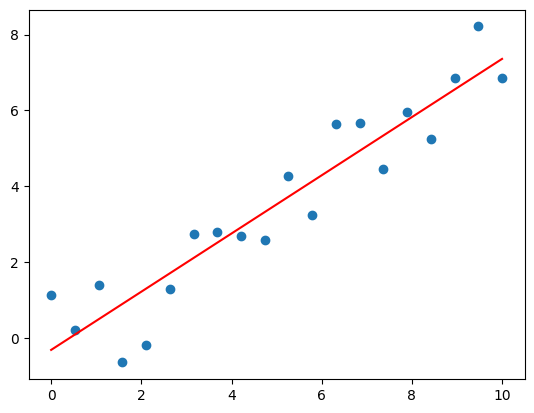

In [ ]:
ruido = np.random.randn(20) #10 puntos randoms
hx = np.linspace(0,10,20)   #Genera 10 puntos equispaciados en [0,10]
hy = []
for i in range(len(hx)):
  hy.append(f(hx[i]))

#Generamos de forma artificial las mediciones
hyRuido = hy +ruido

pol = np.polyfit(hx,hyRuido,1) #Generamos el ajuste del polinomio

#Generamos la recta
px = [0,10]
py = []
py.append(np.polyval(pol,0))
py.append(np.polyval(pol,10))

plt.scatter(hx,hyRuido) #Puntos con ruido
plt.plot(px,py , color = "red")

**Ejercicio 1 (d)** Encontrar el valor de $m$ tal que la recta $y =m(x-\frac{1}{2})$ ajuste lo mejor posible los datos del item anterior en el sentido de cuadrados mínimos.

Respuesta: Usando la aproximación por cuadrados mínimos para $n+1$ puntos de la forma: $$E(m) = \sum_{i=0}^n \left[ m\cdot \left(x_i - \frac{1}2 - y_i\right)\right]^2$$

Buscando el mínimo mediante el uso de derivadas parciales resulta en:

$$m = \frac{\sum_{i=0}^n x_i y_i - 0.5 \sum_{i=0}^n y_i}{\sum_{i=0}^n x_i^2 - \sum_{i=0}^n x_i + n/4}$$

In [ ]:
#Trabajamos con hx y hyRuido
n = len(hx)
xiyi =0
yi =0
xi2=0
xi =0

for i in range(n):
  xiyi+=hx[i]
  yi += hyRuido[i]
  xiyi += hx[i]*hyRuido[i]
  xi2 += hx[i]**2

#Determinamos el valor de m con lo obtenido
m = (xiyi - 0.5*yi) /(xi2 - xi + n/4)

#Estructuramos la función para la grafica:
I = [0,10]
fun = [m,-1/2*m]
funval = []
funval.append(np.polyval(fun, 0))
funval.append(np.polyval(fun, 10))

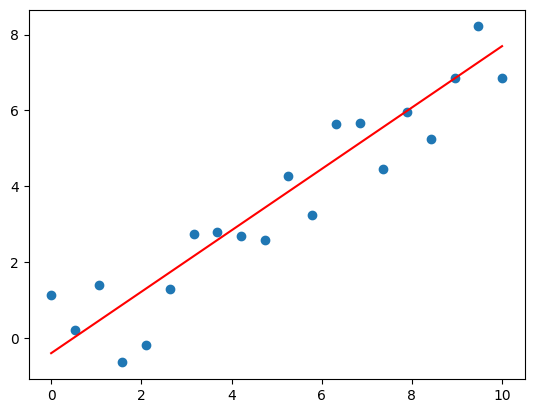

In [ ]:
#Graficando
plt.scatter(hx,hyRuido)
plt.plot(I,funval, color="red")

In [ ]:
#Ayuda para practico
x = [0,1,2,3,4,5,6,7,8,9,10]
y = [1.8,3.5,2.1,-1.0,-3.3,-2.7,0.9,3.3,2.8,-0.1,-3.0]

cos2 = 0
sencos = 0
yicos = 0
for i in range(len(x)):
  cos2+=math.sin(i)**2
  sencos+= math.sin(i)*math.cos(i)
  yicos+=y[i]*math.sin(i)
print(cos2,sencos,yicos)

5.00143063348552 0.3232528470190806 16.077733213290713


**Ejercicio 2** Para las siguientes funciones genera un conjunto de datos $(x_i,y_i), i = 0 ,\dots, 49$ y realizar un ajuste polinomioal de grado $n$ con $n = 0 \dots, 5$:

a) $f(x) = \text{arcsen}(x), \ x \in [0,1]$

b) $g(x) = \cos(x), \ x \in [0,4\pi]$

Estudiar en cada caso la suma de los residuos

In [ ]:
def arcoSeno(x):
  return math.asin(x)

In [ ]:
#Ejercicio 2a.

#Generamos los puntos equispaciados
hx = []
for i in range(50):
  hx.append(0+(i/49))

#Generamos los puntos de la función
hf = []
for i in range(50):
  hf.append(arcoSeno(hx[i]))

#Generamos los puntos con ruido
ruidox50 = np.random.randn(50)
hfruido = hf + ruidox50

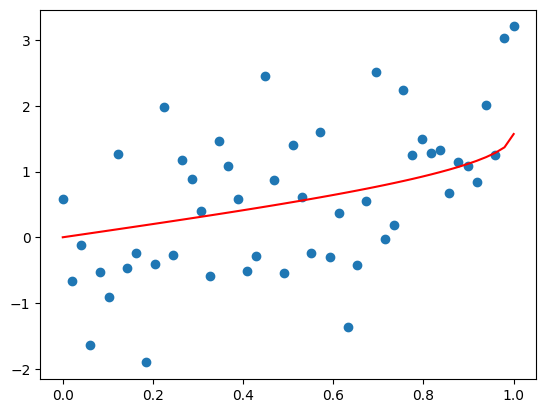

In [ ]:
#grafica
plt.plot(hx,hf,color="red") #arcsen(x), x \in [0,1]
plt.scatter(hx,hfruido)     #Puntos dispersos

In [ ]:
coefPol0t5 = [] #Lista con lista de coeficientes
for i in range(6):
  coefPol0t5.append(np.polyfit(hx,hfruido,i))

pxi = [[],[],[],[],[],[]] #Lista con los puntos ajustado de grado 0 a 5
for i in range(6):
  for j in hx:
    pxi[i].append(np.polyval(coefPol0t5[i],j))

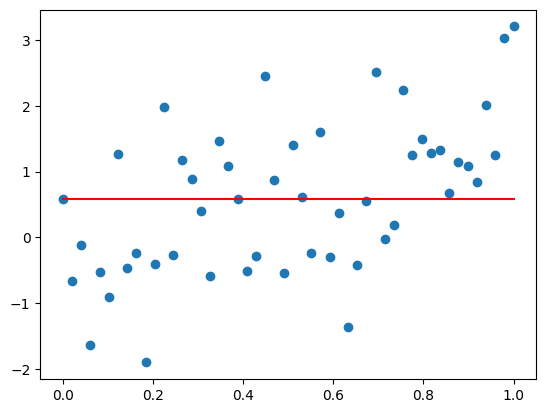

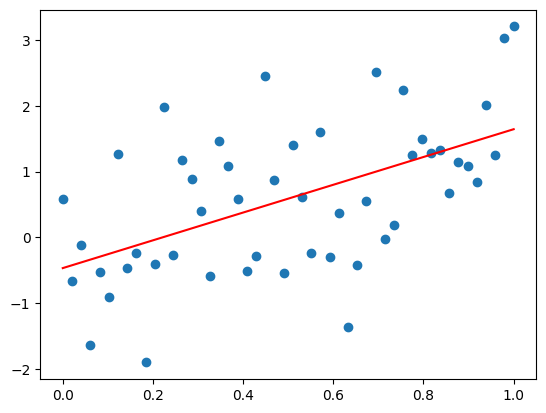

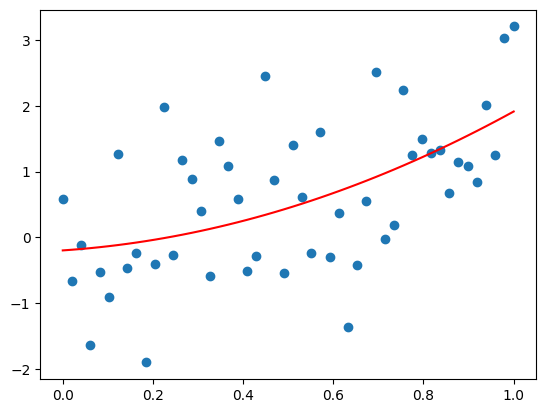

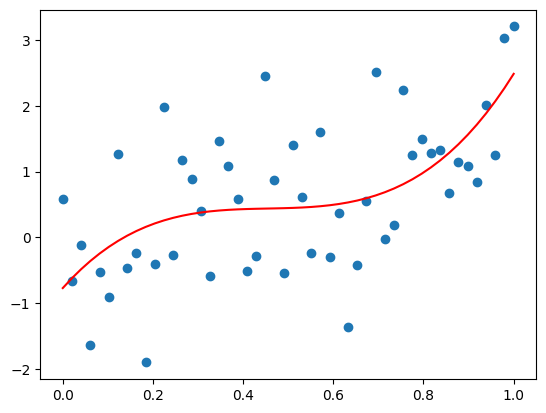

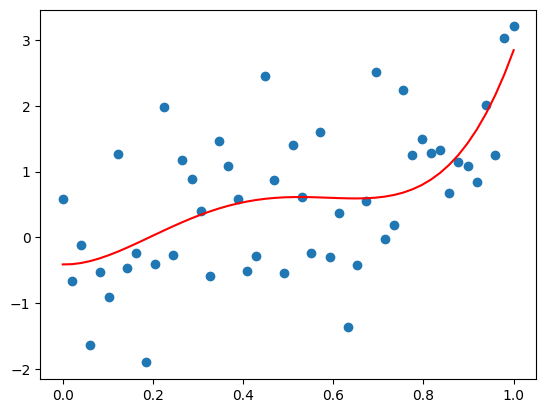

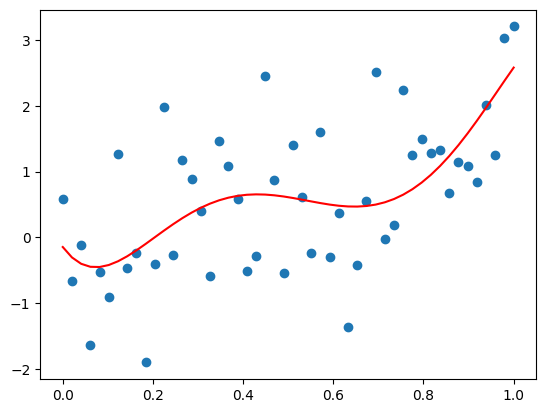

<Figure size 640x480 with 0 Axes>

In [ ]:
#Hacemos una grafica por aproximación de grado
for i in range(6):
  plt.plot(hx,pxi[i],color="red")
  plt.scatter(hx,hfruido)
  plt.figure()

Ejercicio 2b. Desarrollo:

b) $g(x) = \cos(x), \ x \in [0,4\pi]$

In [ ]:
def coseno(x):
  return math.cos(x)

In [ ]:
#Generamos los puntos equispaciados
hx = np.linspace(0,4*np.pi,50)

#Generamos los puntos de la función
hf = []
for i in range(50):
  hf.append(coseno(hx[i]))

#Generamos los puntos con ruido
ruidox50 = np.random.randn(50)
hfruido = hf + ruidox50

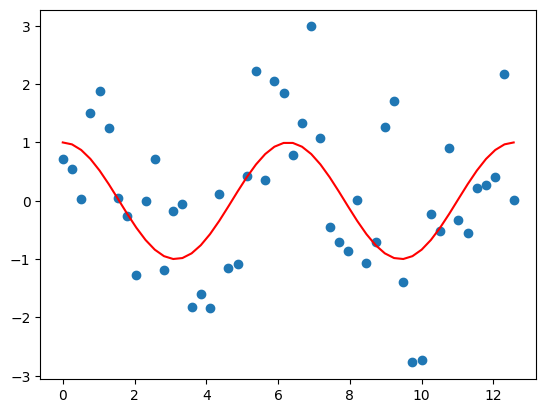

In [ ]:
#Grafico de los puntos con ruido al a función
plt.plot(hx,hf,color="red") #cos(x), x \in [0,4\pi]
plt.scatter(hx,hfruido)     #Puntos equidistantes con ruido

In [ ]:
coefPol0t4pi = [] #Lista con lista de coeficientes
for i in range(6):
  coefPol0t4pi.append(np.polyfit(hx,hfruido,i))

pxi = [[],[],[],[],[],[]] #Lista con los puntos ajustado de grado 0 a 4pi
for i in range(6):
  for j in hx:
    pxi[i].append(np.polyval(coefPol0t4pi[i],j))

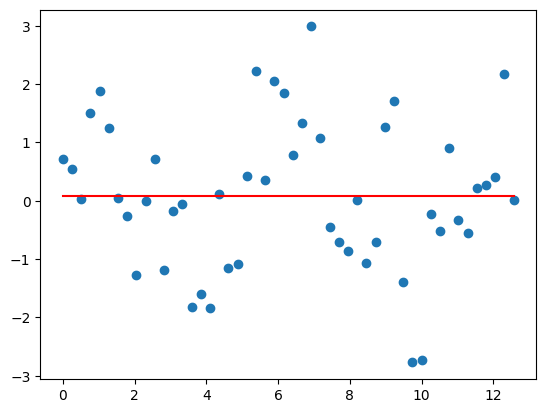

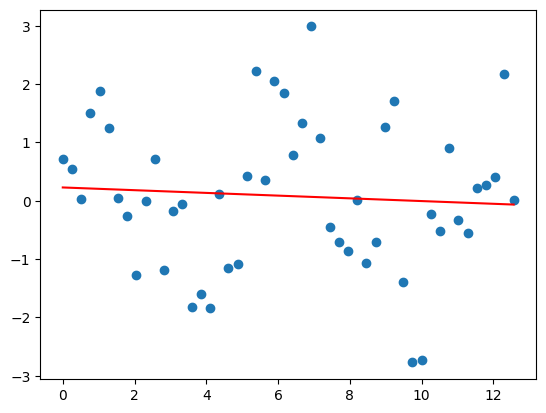

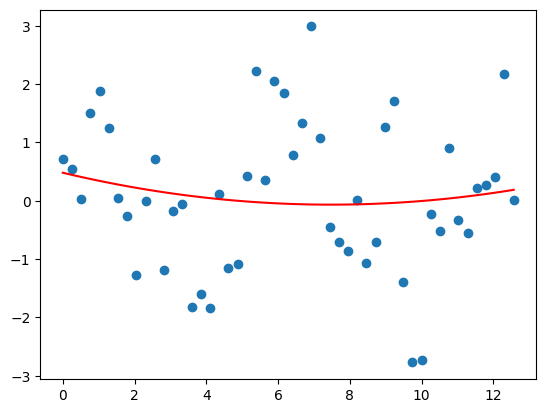

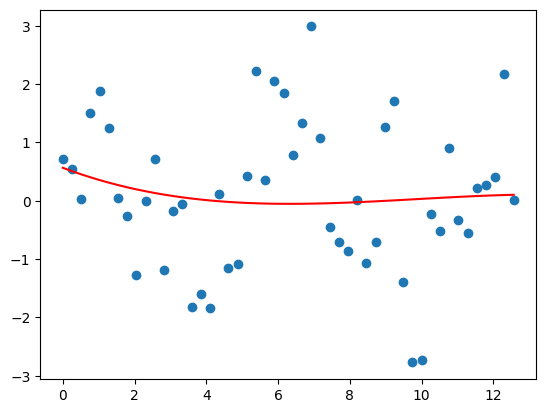

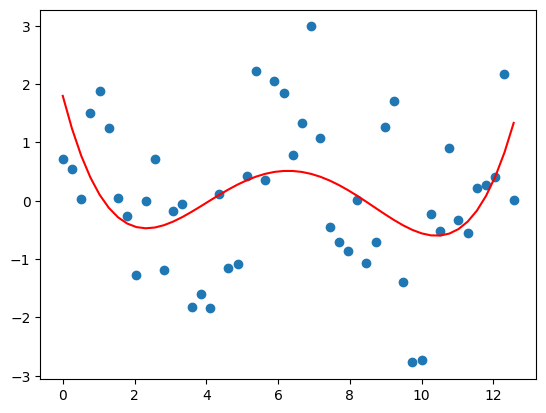

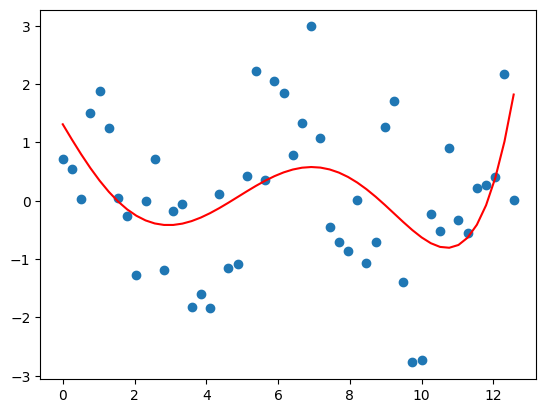

<Figure size 640x480 with 0 Axes>

In [ ]:
#Hacemos una grafica por aproximación de grado
for i in range(6):
  plt.plot(hx,pxi[i],color="red")
  plt.scatter(hx,hfruido)
  plt.figure()

!-Preguntar en clase a que se refiere el ejercicio por "residuo"

**Ejercicio 3)** Obtener los datos almacenados en los archivos `datos3a.dat` y `datos3b.dat` para realizar el ajuste de los siguientes modelos, es decir, determinar los coeficientes de cada modelo

$$(a) \ \ y(x) =Cx^A, \\ (b) \ \ \frac{x}{Ax+B} $$

Ayuda: Transformar en cada caso la expresión dada a un modelo lineal y obtener una recta que mejor ajusta los datos (transformados) en el sentido de mínimos cuadrados.

In [ ]:
#Carga de datos
datos1 = "datos3a.dat"
datos2 = "datos3b.dat"

hd1 = np.loadtxt(datos1)
hd2 = np.loadtxt(datos2)

Transformo la expresión (a) a un modelo lineal tal que

$$ln(y_i) = ln(c) + A \cdot ln(x_i)$$

In [ ]:
#Redefino la nueva tabla de valores
lnxi = np.log(hd1[0]) #ln(x_i)
lnyi = np.log(hd1[1]) #ln(y_i)

In [ ]:
def funcion(x, coef):
    A = coef[0]
    C = np.exp(coef[1])
    return C * (x ** A)

In [ ]:
pol_ajustadoa = np.polyfit(lnxi,lnyi,1)
print(pol_ajustadoa) #=A,ln(c)

# Genero los puntos de la función
hx = np.linspace(1,5,10)
hy = funcion(hx,pol_ajustadoa)

[2.99780896 0.6959328 ]


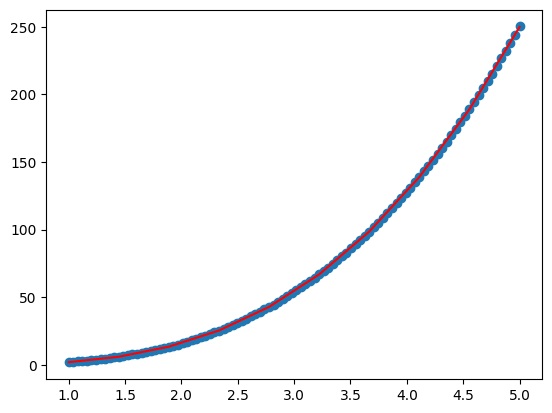

In [ ]:
plt.plot(hx,hy,color="red")
plt.scatter(hd1[0],hd1[1])

3b. Transformo la función a:

$$\frac{1}y = B \cdot \frac{1}{x}+ A$$

In [ ]:
# Usamos desde el segundo elemento en adelante para evitar el 1/0
inv_xi = 1.0 / hd2[0][1:]
inv_yi = 1.0 / hd2[1][1:]

In [ ]:
def funcion_b(x, coef):
    B = coef[0]
    A = coef[1]
    return x / (A * x + B)

In [ ]:
pol_ajustadob = np.polyfit(inv_xi, inv_yi, 1)

# Empezamos en 0.1 en lugar de 0
hxb = np.linspace(0.1, 20, 100)
hyb = funcion_b(hxb, pol_ajustadob)

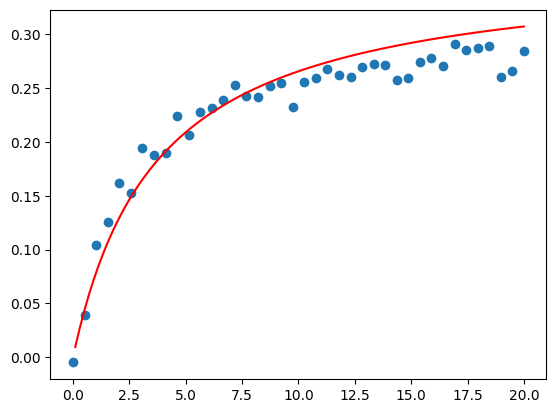

In [ ]:
plt.scatter(hd2[0],hd2[1])
plt.plot(hxb,hyb,color="red")

**Ejercicio 4** Italia fue el país más afectado por el Coronavirus, comenzando con 14 casos desde el 22 de febrero en 2020 y con una cantidad de infectados que creció exponencialmente por más de un mes. Obtener los datos almacenados en el archivo `covid_italia.csv` y realizar un ajuste exponencial de la forma $y(x)=ae^{bx}$. Realizar un gráfico que contenga los datos y el ajuste

In [ ]:
# Cargar los datos especificando el delimitador
datos = np.loadtxt("covid_italia.csv", delimiter=",", skiprows=1)

# Separar las columnas en variables (X e Y)
x = datos[:, 0]  # Primera columna
y = datos[:, 1]  # Segunda columna

Rehago la función:
$$y = ae^{bx}$$
$$\ln(y_i) = bx_i + \ln(a)$$

In [ ]:
lny4 = np.log(y)
CoefPolinomio = np.polyfit(x,lny4,1)

In [ ]:
def funcion4(x,coef):
  bx = coef[0]*x
  a = np.exp(coef[1])
  return a*(np.e**(bx))

In [ ]:
hx4 = np.linspace(1,40,100)
hy4 = []
hx4 = np.linspace(1, 40, 100)
hy4 = funcion4(hx4, CoefPolinomio)

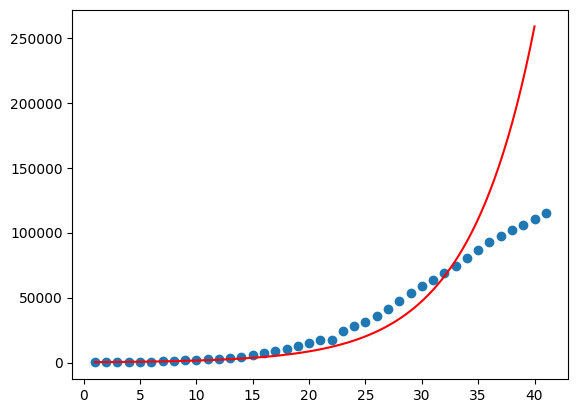

In [ ]:
plt.plot(hx4,hy4,color="red")
plt.scatter(x,y)